<div style="display:flex; align-items:center; gap:18px; text-align:left">
  <img src="https://sebastiancontz.github.io/ust-diplomado-ia-curso-intro-ia/assets/logo-ust.svg" width="100" alt="Logo Universidad Santo Tomás">
  <div>
    <p>Diplomado en Inteligencia Artificial para los Negocios</p>
    <p>Facultad de Ingeniería y Negocios</p>
    <p>Módulo 3 · Introducción a la Inteligencia Artificial Generativa</p>
    <p>Semana 02: Cómo funcionan los modelos generativos y multimodales</p>
  </div>
</div>

# Taller de Experimentación y Decisión Directiva

<a href="https://colab.research.google.com/github/sebastiancontz/ust-diplomado-ia-curso-intro-ia-colab/blob/main/ediciones/2026/notebooks/02-como-funcionan-modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bienvenidas y bienvenidos al taller práctico de la **Clase 02**.

En esta sesión desmitificamos la física interna de los modelos de lenguaje (LLMs) y los modelos multimodales.

Este cuaderno está diseñado con un enfoque **100% directivo y analítico (sin necesidad de escribir código)**:
- No necesitan programar scripts ni recordar sintaxis de Python.
- Las celdas de cálculo operan como **formularios interactivos** con perillas, listas desplegables y parámetros configurables.
- Su foco está en el **análisis de escenarios, la gobernanza de riesgos y la toma de decisiones financieras**.

### Objetivos del taller
1. **Familiarizarse con Google Colab:** Conocer el entorno digital de trabajo sin estrés de programación antes de las sesiones de código aplicado.
2. **Bitácora de experimentación en Google AI Studio:** Registrar y consolidar las observaciones empíricas sobre fragmentación de tokens en español (factor 1.6), costos multimodales y modulación de temperatura ($T$) y Top_p.
3. **Simulador directivo de tokens y costos:** Evaluar el impacto presupuestario de operar un modelo propio on-premise frente a consumir servicios API en la nube para volúmenes reales de negocio.
4. **Ficha de Decisión Directiva:** Justificar la arquitectura técnica, parámetros de inferencia y salvaguardas de privacidad para dos organizaciones con requerimientos opuestos: un estudio jurídico corporativo y una agencia de marketing digital.

## 1. Instrucciones de uso en Google Colab

Para trabajar de forma ordenada en este taller:
1. **Guardar su copia de trabajo:** Hagan clic en el menú **Archivo** $\rightarrow$ **Guardar una copia en Drive**. De este modo, sus respuestas y cálculos quedarán almacenados en su cuenta personal o institucional de Google.
2. **Ejecución de celdas interactivas:** Para ejecutar una celda de cálculo, hagan clic en el botón de reproducción (**Play** / ▶) ubicado a la izquierda de la celda, o presionen `Ctrl + Enter` estando dentro de ella.
3. **Formularios sin código (Colab Forms):** Las celdas técnicas tienen el código oculto y muestran un formulario visual. Solo deben modificar los valores en los casilleros y presionar Play para actualizar los resultados.
4. **Completar respuestas de texto:** Para responder las preguntas de análisis directivo, hagan doble clic sobre las celdas de texto correspondientes, completen sus respuestas en los casilleros indicados y presionen `Shift + Enter` para guardar.

## 2. Bitácora de experimentación en Google AI Studio

Entorno de experimentación en vivo: [**aistudio.google.com**](https://aistudio.google.com)

Durante la primera parte del taller exploramos tres fenómenos clave de los modelos fundacionales. Utilicen la siguiente pauta para registrar sus observaciones de auditoría técnica:

### Ejercicio A · El impuesto al español y multimodalidad
- **Prueba de texto:** Contrastar la frase en inglés (*"The company reported solid earnings this quarter"*) frente a su traducción al español (*"La compañía reportó ganancias sólidas en este trimestre"*).
- **Prueba de imagen:** Cargar una imagen (gráfico contable o factura escaneada) en el prompt y observar el conteo de tokens asignado (~258 tokens visuales).

### Ejercicio B · Prueba de consistencia estricta ($T = 0.0$)
- **Consigna:** Extraer cliente, monto, fecha y estado de pago del caso *Constructora del Sur SpA*.
- **Calibración:** Fijar Temperatura en **0.0** y ejecutar la solicitud 2 veces consecutivas para comprobar reproducibilidad idéntica.

### Ejercicio C · Prueba creativa y corte estadístico con Top_p
- **Consigna:** Redactar 3 eslóganes comerciales para café sustentable chileno.
- **Calibración 1:** Temperatura **1.3** con Top_p **0.95** (evaluar variedad léxica).
- **Calibración 2:** Temperatura **1.3** con Top_p **0.10** (evaluar empobrecimiento forzado hacia la punta de la campana).

### Registro de observaciones (Bitácora del estudiante)

Completen la siguiente tabla haciendo doble clic sobre esta celda:

| Prueba realizada | Tokens observados | Comportamiento del modelo | Conclusión directiva para la empresa |
|:---|:---:|:---|:---|
| **Texto en inglés** | *[ej. 8 tokens]* | Frase concisa en inglés. | Línea base de costo estándar. |
| **Texto en español** | *[ej. 12 tokens]* | Fragmentación en subpalabras por vocabulario BPE. | **Impuesto al español:** ~50% más de costo en tokens para procesar el mismo contenido. |
| **Imagen multimodal** | *[ej. 258 tokens]* | Cuadrícula de parches (*patches*) visuales procesados como tokens fijos. | El costo de auditar una factura escaneada es predecible e independiente del texto visible. |
| **Consistencia ($T=0.0$)** | *[Tokens]* | Estructura y cifras idénticas en ambas corridas. | **Estándar innegociable en auditoría y finanzas:** cero dispersión estocástica. |
| **Creatividad ($T=1.3$)** | *[Tokens]* | Opciones diversas y vocabulario publicitario rico. | Apto para ideación y marketing; inaceptable para contratos o balances. |
| **Corte Top_p ($0.10$)** | *[Tokens]* | Frases obvias y monótonas pese a la alta temperatura. | Top_p anula la creatividad al descartar el 90% del vocabulario disponible. |

## 3. Simulador directivo de tokens y costos

La siguiente celda interactiva permite calcular el presupuesto mensual y comparar las dos alternativas de infraestructura corporativa:
1. **Servicio API en la nube:** Modelo comercial con pago por uso exacto (tarifas estándar: $0.15 USD por millón de tokens de entrada / $0.60 USD por millón de salida).
2. **Servidor Propio On-Premise:** Arriendo de servidor corporativo con GPUs dedicadas ($1.200 USD fijos al mes, se use o no).

### Instrucciones:
- Seleccionen en la lista desplegable el **escenario** a evaluar (*Caso 1: Estudio Jurídico Velasco & Asoc.* o *Caso 2: Agencia Digital CreaImpacto*).
- Hagan clic en el botón **Play** (▶) a la izquierda para calcular el balance financiero y ver el diagnóstico automatizado.

In [1]:
#@title Simulador Directivo de Tokens y Costos { run: "auto" }
#@markdown Ingrese o seleccione los parámetros operativos a simular:

escenario = "Caso 1: Estudio Jurídico Velasco & Asoc. (Legal)"  #@param ["Caso 1: Estudio Jurídico Velasco & Asoc. (Legal)", "Caso 2: Agencia Digital CreaImpacto (Marketing)", "Personalizado"]
volumen_documentos_mes = 400  #@param {type:"integer"}
palabras_entrada_por_doc = 10000  #@param {type:"integer"}
palabras_salida_por_doc = 500  #@param {type:"integer"}
factor_espanol = 1.6  #@param {type:"number"}
tarifa_entrada_usd_m = 0.15  #@param {type:"number"}
tarifa_salida_usd_m = 0.60  #@param {type:"number"}
costo_fijo_servidor_usd = 1200.0  #@param {type:"number"}

# Carga automática de parámetros según el caso seleccionado
if escenario == "Caso 1: Estudio Jurídico Velasco & Asoc. (Legal)":
    volumen_documentos_mes = 400
    palabras_entrada_por_doc = 10000
    palabras_salida_por_doc = 500
    tarifa_entrada_usd_m = 0.15
    tarifa_salida_usd_m = 0.60
    costo_fijo_servidor_usd = 1200.0
elif escenario == "Caso 2: Agencia Digital CreaImpacto (Marketing)":
    volumen_documentos_mes = 2500
    palabras_entrada_por_doc = 200
    palabras_salida_por_doc = 400
    tarifa_entrada_usd_m = 0.15
    tarifa_salida_usd_m = 0.60
    costo_fijo_servidor_usd = 1200.0

# 1. Estimación de tokens con la heurística de español (palabras x 1.6)
tokens_entrada_doc = int(palabras_entrada_por_doc * factor_espanol)
tokens_salida_doc = int(palabras_salida_por_doc * factor_espanol)

tokens_entrada_mes = tokens_entrada_doc * volumen_documentos_mes
tokens_salida_mes = tokens_salida_doc * volumen_documentos_mes
tokens_totales_mes = tokens_entrada_mes + tokens_salida_mes

# 2. Estimación de costos en la nube (API)
costo_api_entrada_usd = (tokens_entrada_mes / 1_000_000) * tarifa_entrada_usd_m
costo_api_salida_usd = (tokens_salida_mes / 1_000_000) * tarifa_salida_usd_m
costo_api_total_usd = costo_api_entrada_usd + costo_api_salida_usd
costo_servidor_total_usd = costo_fijo_servidor_usd

diferencia_usd = abs(costo_servidor_total_usd - costo_api_total_usd)
ratio = costo_servidor_total_usd / costo_api_total_usd if costo_api_total_usd > 0 else 0

# 3. Renderizado del reporte ejecutivo
from IPython.display import display, Markdown

reporte = f"""
### Balance de Procesamiento y Costos Mensuales
**Escenario evaluado:** {escenario}

| Dimensión Operativa | Entrada (Prompts / Documentos) | Salida (Respuestas / Fichas) | Consolidado Mensual |
|:---|:---:|:---:|:---:|
| **Palabras por unidad** | {palabras_entrada_por_doc:,} palabras | {palabras_salida_por_doc:,} palabras | - |
| **Tokens unitarios (x{factor_espanol})** | {tokens_entrada_doc:,} tokens | {tokens_salida_doc:,} tokens | - |
| **Volumen mensual** | {volumen_documentos_mes:,} documentos | {volumen_documentos_mes:,} fichas | - |
| **Tokens mensuales** | **{tokens_entrada_mes:,}** | **{tokens_salida_mes:,}** | **{tokens_totales_mes:,} tokens** |
| **Tarifa de mercado (/1M)** | ${tarifa_entrada_usd_m:.2f} USD | ${tarifa_salida_usd_m:.2f} USD | - |
| **Costo API en la nube** | **${costo_api_entrada_usd:.2f} USD** | **${costo_api_salida_usd:.2f} USD** | **${costo_api_total_usd:.2f} USD/mes** |

---

### Comparación Financiera Directiva
- **Costo mensual del servicio API en la nube:** **${costo_api_total_usd:.2f} USD/mes**
- **Costo mensual de servidor dedicado propio (GPU):** **${costo_servidor_total_usd:.2f} USD/mes**
- **Brecha financiera mensual:** **${diferencia_usd:.2f} USD/mes** (Servidor propio es **{ratio:,.1f} veces** el costo de la nube)
"""
display(Markdown(reporte))

# 4. Dictamen directivo automatizado
if escenario.startswith("Caso 1"):
    dictamen = (
        "> **Dictamen directivo para Caso 1 (Estudio Jurídico):**\n"
        "> Aunque la API en la nube costaría apenas **$1.15 USD/mes**, la decisión de asumir un costo de **$1.200 USD/mes** "
        "> en infraestructura propia se justifica exclusivamente por **secreto profesional estricto y gobernanza de datos** "
        "> (prohibición contractual de que contratos de M&A salgan a la red pública).\n"
        "> La diferencia de $1.198,85 USD/mes no es un sobrecosto tecnológico: es la prima de seguro institucional de confidencialidad."
    )
elif escenario.startswith("Caso 2"):
    dictamen = (
        "> **Dictamen directivo para Caso 2 (Agencia Digital):**\n"
        "> Para una agencia con requerimiento de salida a producción inmediata y presupuesto acotado, "
        "> operar un servidor GPU propio de $1.200 USD/mes constituiría una severa ineficiencia financiera.\n"
        "> La API con contrato corporativo estándar cuesta apenas **$0.72 USD/mes**, escala elásticamente y "
        "> no demanda pagar salarios a ingenieros dedicados de infraestructura."
    )
else:
    dictamen = f"> **Dictamen directivo:** La diferencia neta entre nube y servidor propio es de ${diferencia_usd:.2f} USD/mes. Evalúen si su mandato de privacidad justifica la inversión en infraestructura fija."

display(Markdown(dictamen))


### Balance de Procesamiento y Costos Mensuales
**Escenario evaluado:** Caso 1: Estudio Jurídico Velasco & Asoc. (Legal)

| Dimensión Operativa | Entrada (Prompts / Documentos) | Salida (Respuestas / Fichas) | Consolidado Mensual |
|:---|:---:|:---:|:---:|
| **Palabras por unidad** | 10,000 palabras | 500 palabras | - |
| **Tokens unitarios (x1.6)** | 16,000 tokens | 800 tokens | - |
| **Volumen mensual** | 400 documentos | 400 fichas | - |
| **Tokens mensuales** | **6,400,000** | **320,000** | **6,720,000 tokens** |
| **Tarifa de mercado (/1M)** | $0.15 USD | $0.60 USD | - |
| **Costo API en la nube** | **$0.96 USD** | **$0.19 USD** | **$1.15 USD/mes** |

---

### Comparación Financiera Directiva
- **Costo mensual del servicio API en la nube:** **$1.15 USD/mes**
- **Costo mensual de servidor dedicado propio (GPU):** **$1200.00 USD/mes**
- **Brecha financiera mensual:** **$1198.85 USD/mes** (Servidor propio es **1,041.7 veces** el costo de la nube)


> **Dictamen directivo para Caso 1 (Estudio Jurídico):**
> Aunque la API en la nube costaría apenas **$1.15 USD/mes**, la decisión de asumir un costo de **$1.200 USD/mes** > en infraestructura propia se justifica exclusivamente por **secreto profesional estricto y gobernanza de datos** > (prohibición contractual de que contratos de M&A salgan a la red pública).
> La diferencia de $1.198,85 USD/mes no es un sobrecosto tecnológico: es la prima de seguro institucional de confidencialidad.

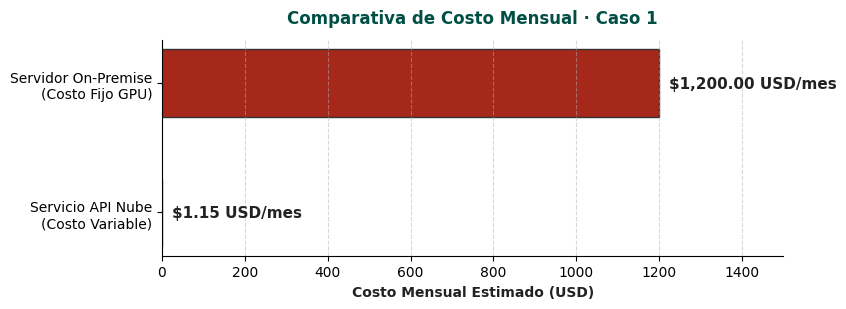

In [2]:
#@title Visualización Gráfica: Comparativa Financiera Mensual (USD) { run: "auto" }
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 3.2), dpi=100)

opciones = ['Servicio API Nube\n(Costo Variable)', 'Servidor On-Premise\n(Costo Fijo GPU)']
valores = [costo_api_total_usd, costo_servidor_total_usd]
colores = ['#004F45', '#A5281B']

barras = ax.barh(opciones, valores, color=colores, height=0.52, edgecolor='#333333', linewidth=1)

# Etiquetas numéricas legibles sobre las barras
for barra, val in zip(barras, valores):
    ancho = barra.get_width()
    ax.text(ancho + (max(valores) * 0.02), barra.get_y() + barra.get_height() / 2,
            f'${val:,.2f} USD/mes',
            va='center', ha='left', fontsize=11, fontweight='bold', color='#222222')

ax.set_xlim(0, max(valores) * 1.25)
ax.set_xlabel('Costo Mensual Estimado (USD)', fontsize=10, fontweight='bold', color='#222222')
titulo_caso = escenario.split(':')[0] if ':' in escenario else escenario
ax.set_title(f'Comparativa de Costo Mensual · {titulo_caso}', fontsize=12, fontweight='bold', color='#004F45', pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Ficha de Decisión Directiva y Calibración Técnica

En esta sección de trabajo autónomo en parejas (Fase 3: *Ustedes lo hacen*), documentarán las decisiones estratégicas para ambos casos de negocio.

Hagan doble clic sobre cada ficha y completen los cuadrantes con su diagnóstico profesional:

### Ficha de Decisión · Caso 1: Estudio Jurídico "Velasco & Asoc."

| Cuadrante de Decisión | Elección Técnica / Directiva | Justificación Profesional y de Negocio |
|:---|:---|:---|
| **1. Gobernanza de Arquitectura** | *[¿Servidor propio on-premise o API comercial?]* | *[Justificar según secreto profesional, confidencialidad legal y marco DPA]* |
| **2. Calibración de Inferencia** | **Temperatura:** *[0.0 - 0.2]* <br> **Top_p:** *[0.90]* | *[Justificar la necesidad de consistencia determinista estricta en cláusulas contractuales]* |
| **3. Delimitación de Contexto** | **Indispensable:** *[Contrato pertinente]* <br> **Excluir:** *[PII no relevante]* | *[Criterio de minimización de datos y contención del sesgo Lost in the Middle]* |
| **4. Evaluación Presupuestaria** | **Costo Servidor:** $1.200 USD <br> **Costo API:** $1.15 USD | *[Conclusión directiva: ¿por qué la empresa acepta un sobrecosto del 104.000%?]* |

---

### Ficha de Decisión · Caso 2: Agencia Digital "CreaImpacto"

| Cuadrante de Decisión | Elección Técnica / Directiva | Justificación Profesional y de Negocio |
|:---|:---|:---|
| **1. Gobernanza de Arquitectura** | *[¿Servidor propio on-premise o API comercial?]* | *[Justificar según Time-to-Market (2 semanas), inversión de capital y soporte de ingeniería]* |
| **2. Calibración de Inferencia** | **Temperatura:** *[1.1 - 1.3]* <br> **Top_p:** *[0.95]* | *[Justificar la búsqueda de variedad léxica, originalidad publicitaria y frescura de redacción]* |
| **3. Delimitación de Contexto** | **Indispensable:** *[Brief de campaña]* <br> **Excluir:** *[Estrategias no públicas]* | *[Criterio de brevedad en el prompt para asegurar velocidad de respuesta]* |
| **4. Evaluación Presupuestaria** | **Costo Servidor:** $1.200 USD <br> **Costo API:** $0.72 USD | *[Conclusión directiva: ¿por qué el pago por uso es la única decisión viable aquí?]* |

## 5. Puesta en común y conclusiones directivas

Para consolidar lo aprendido en este taller, revisemos los cuatro principios rectores que deben orientar las decisiones de tecnología en sus organizaciones:

1. **La privacidad tiene precio de infraestructura:** La soberanía de datos total mediante modelos de pesos abiertos en servidores locales exige costos fijos predecibles pero elevados ($1.200+ USD/mes en hardware GPU). La nube ofrece costos variables marginales, pero requiere contratos corporativos formales (**DPA**) con cláusula de no entrenamiento y retención cero.
2. **El impuesto lingüístico es real:** El español consume aproximadamente un **50% a 60% más de tokens** que el inglés por la fragmentación subpalabra del algoritmo BPE. Todo presupuesto y dimensionamiento de ventana de contexto en América Latina debe incorporar el factor $1.6$.
3. **Temperatura cero para control y finanzas:** En tareas de extracción contable, conciliación, auditoría o estructuración legal, la temperatura debe fijarse estrictamente en **0.0**. En estas áreas, la estocasticidad o la "creatividad" léxica constituyen un fallo operacional severo.
4. **La perilla de control único:** Al calibrar modelos en producción, modulen la Temperatura o modulen Top_p, pero eviten mover ambos controles de manera simultánea sin una hipótesis de diseño clara.

## Atribución de datos

- **Creador:** Sebastián Contreras
- **Procedencia:** Casos sintéticos elaborados con fines docentes para ilustrar auditoría técnica, privacidad y evaluación directiva de costos en IA. No representan a organizaciones, estudios jurídicos ni agencias reales.
- **Modificación:** Ninguna.